# End-to-End Leaf Disease Demo (Thesis)

This notebook demonstrates the full pipeline on a **static image**:

1. **Leaf detection (ESPDet-Pico, `.pt`)** → bounding boxes (filtered by confidence threshold only)
2. **Crop & save** each detected leaf ROI
3. **Disease classification (MobileNet, `.pth`)** on each crop
4. Show: annotated image, crop gallery, per-leaf predictions table, and saved artifacts.

> **Note:** ESPDet-Pico is not a standard YOLO; loading requires `custom_parse_model` from the project (`nn.esp_tasks`) and patching `ultralytics.nn.tasks.parse_model`.


In [62]:
# ==== CONFIG (edit paths if needed) ====
from pathlib import Path

imgPath = Path("/home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/examples/grape_leafe_detection/grape_vine.jpg")

leafDetectorPath = Path("/home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/runs/detect/train/weights/best.pt")

# MobileNet disease classifier (PyTorch .pth)
mobileNetPath = Path("/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/finetuned_mobilenet_128.pth")

# Detection: confidence threshold ONLY (no Top-K)
DET_CONF_THRESH = 0.35

# Classifier - MUST match the training class order!
# Training used: ['Black_rot', 'Esca', 'Leaf_blight', 'Healthy'] (alphabetical from ImageFolder)
DISEASE_CLASSES = ["Black_rot", "Esca", "Leaf_blight", "Healthy"]
CLASSIFIER_INPUT_SIZE = 128  # set to the input size used during MobileNet training (128 or 224)

# Outputs
OUT_DIR = Path("/home/ubuntu/edge-ai-vineyard-monitoring/outputs_thesis_demo")
CROPS_DIR = OUT_DIR / "crops"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CROPS_DIR.mkdir(parents=True, exist_ok=True)

print("Image:", imgPath)
print("Detector:", leafDetectorPath)
print("Classifier:", mobileNetPath)
print("Disease Classes (training order):", DISEASE_CLASSES)
print("Outputs:", OUT_DIR)


Image: /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/examples/grape_leafe_detection/grape_vine.jpg
Detector: /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/runs/detect/train/weights/best.pt
Classifier: /home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/finetuned_mobilenet_128.pth
Disease Classes (training order): ['Black_rot', 'Esca', 'Leaf_blight', 'Healthy']
Outputs: /home/ubuntu/edge-ai-vineyard-monitoring/outputs_thesis_demo


In [63]:
# ==== Imports & small utilities ====
import os, time, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
from torchvision import models, transforms

def show_rgb(img_rgb, title=None, figsize=(10,6)):
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

def ensure_exists(p: Path, what: str):
    if not p.exists():
        raise FileNotFoundError(f"{what} not found: {p}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [64]:
# ==== Load ESPDet-Pico detector (special handling) ====
ensure_exists(imgPath, "Input image")
ensure_exists(leafDetectorPath, "Detector weights")

# Add leaf_detection to sys.path so we can import nn.esp_tasks
import sys
import os

leaf_detection_root = "/home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection"
if leaf_detection_root not in sys.path:
    sys.path.insert(0, leaf_detection_root)
    print(f"✓ Added to sys.path: {leaf_detection_root}")

# Verify the module exists
nn_path = os.path.join(leaf_detection_root, "nn", "esp_tasks.py")
if not os.path.exists(nn_path):
    raise FileNotFoundError(f"esp_tasks.py not found at: {nn_path}")
print(f"✓ Verified esp_tasks.py exists at: {nn_path}")

from ultralytics import YOLO

# ESPDet-Pico special: patch Ultralytics parser
try:
    from nn.esp_tasks import custom_parse_model
    import ultralytics.nn.tasks as tasks
    tasks.parse_model = custom_parse_model
    print("✓ Patched Ultralytics parse_model with custom_parse_model (ESPDet-Pico)")
except Exception as e:
    raise RuntimeError(
        "Failed to import/patch custom_parse_model for ESPDet-Pico. "
        f"Make sure 'nn/esp_tasks.py' exists in {leaf_detection_root}\n"
        f"Original error: {e}"
    )

detector = YOLO(str(leafDetectorPath))
detector.model.to(device).eval()
print("✓ Detector loaded. Classes:", detector.names)

✓ Added to sys.path: /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection
✓ Verified esp_tasks.py exists at: /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/nn/esp_tasks.py
✓ Patched Ultralytics parse_model with custom_parse_model (ESPDet-Pico)
✓ Detector loaded. Classes: {0: 'leaf'}


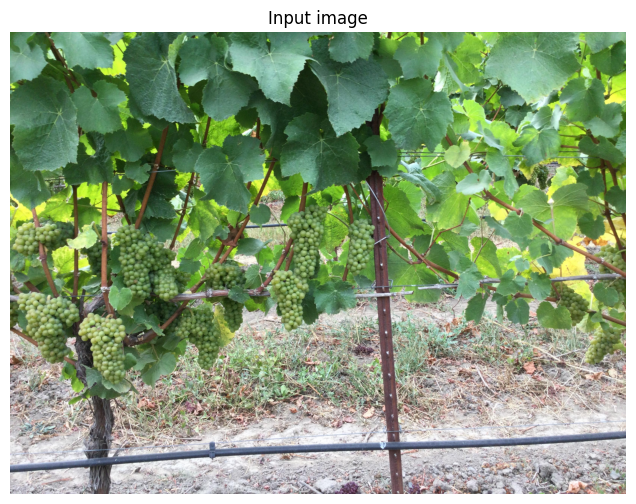

Detector latency: 766.08 ms
Detections kept (conf >= 0.35): 40


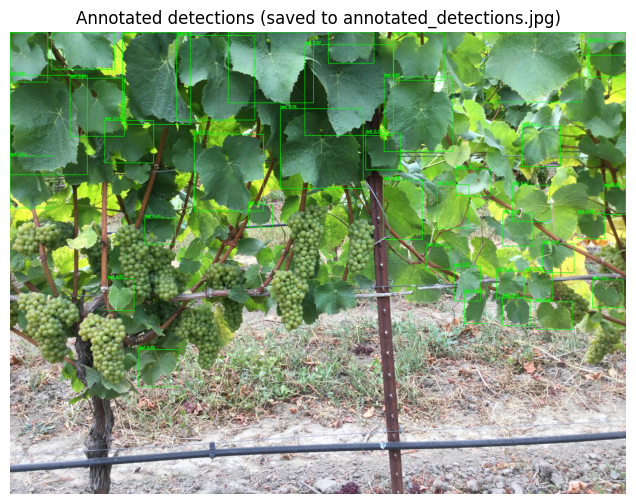

In [65]:
# ==== Run detection, filter by confidence threshold, annotate + save ====
# Read with OpenCV (BGR)
img_bgr = cv2.imread(str(imgPath))
if img_bgr is None:
    raise RuntimeError(f"Failed to read image: {imgPath}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
show_rgb(img_rgb, "Input image")

t0 = time.perf_counter()
# Use Ultralytics predict; ESPDet-Pico uses same Results container once loaded with custom parser
results = detector.predict(source=img_bgr, verbose=False)  # pass ndarray to avoid color confusion
t1 = time.perf_counter()

res = results[0]
if res.boxes is None or len(res.boxes) == 0:
    print("No detections.")
    detections = []
else:
    boxes = res.boxes.xyxy.cpu().numpy()
    confs = res.boxes.conf.cpu().numpy()
    clss  = res.boxes.cls.cpu().numpy().astype(int)

    # confidence-threshold-only filtering
    keep = confs >= DET_CONF_THRESH
    boxes, confs, clss = boxes[keep], confs[keep], clss[keep]

    detections = []
    for i, (xyxy, cf, ci) in enumerate(zip(boxes, confs, clss)):
        x1,y1,x2,y2 = [int(round(v)) for v in xyxy.tolist()]
        # clamp
        h,w = img_bgr.shape[:2]
        x1,y1 = max(0,x1), max(0,y1)
        x2,y2 = min(w-1,x2), min(h-1,y2)
        detections.append({
            "leaf_id": i,
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "det_conf": float(cf),
            "det_class_id": int(ci),
            "det_class_name": str(detector.names.get(int(ci), str(ci)))
        })

print(f"Detector latency: {(t1-t0)*1000:.2f} ms")
print(f"Detections kept (conf >= {DET_CONF_THRESH}): {len(detections)}")

# Annotate and save
annot_bgr = img_bgr.copy()
for d in detections:
    x1,y1,x2,y2 = d["x1"], d["y1"], d["x2"], d["y2"]
    label = f"{d['det_class_name']} {d['det_conf']:.2f}"
    cv2.rectangle(annot_bgr, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(annot_bgr, label, (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

annot_path = OUT_DIR / "annotated_detections.jpg"
cv2.imwrite(str(annot_path), annot_bgr)
show_rgb(cv2.cvtColor(annot_bgr, cv2.COLOR_BGR2RGB), f"Annotated detections (saved to {annot_path.name})")


In [66]:
# ==== Crop detected leaves and save ====
crop_paths = []
for d in detections:
    x1,y1,x2,y2 = d["x1"], d["y1"], d["x2"], d["y2"]
    crop_bgr = img_bgr[y1:y2, x1:x2].copy()
    if crop_bgr.size == 0:
        continue
    crop_name = f"leaf_{d['leaf_id']:03d}_det_{d['det_conf']:.2f}.jpg"
    crop_path = CROPS_DIR / crop_name
    cv2.imwrite(str(crop_path), crop_bgr)
    d["crop_path"] = str(crop_path)
    crop_paths.append(crop_path)

print(f"Saved {len(crop_paths)} crops to: {CROPS_DIR}")


Saved 40 crops to: /home/ubuntu/edge-ai-vineyard-monitoring/outputs_thesis_demo/crops


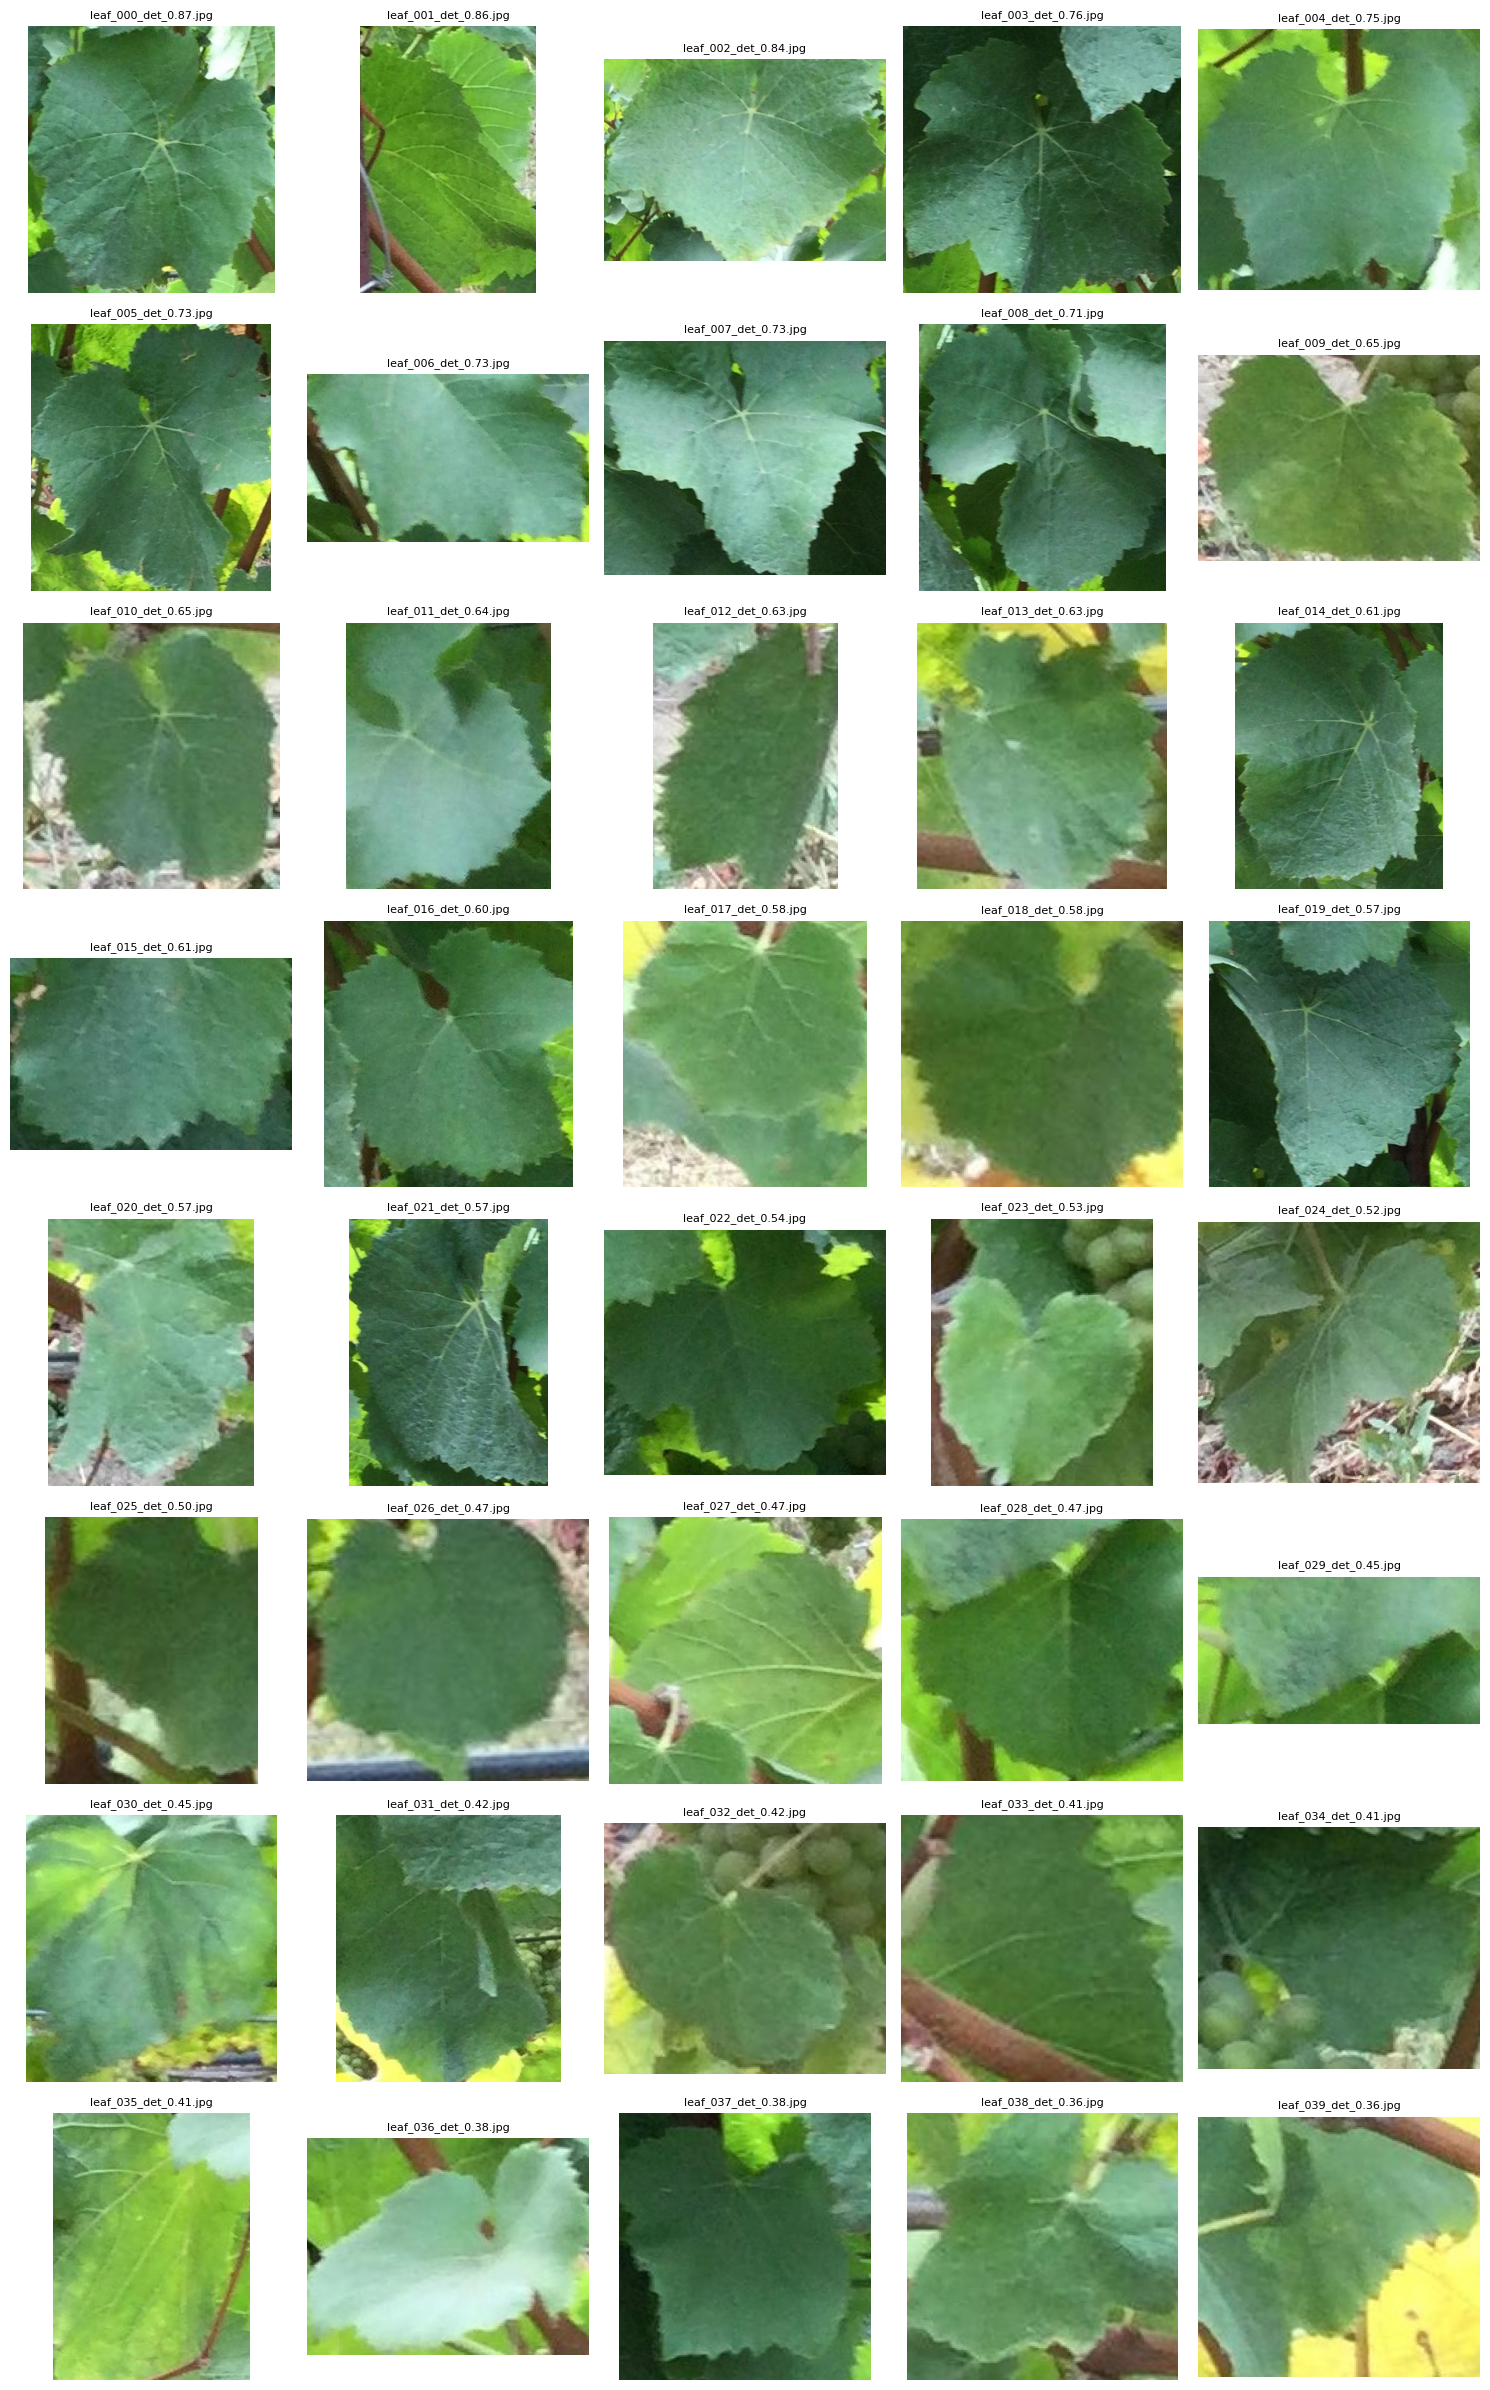

In [7]:
# ==== Show crop gallery in notebook ====
if len(crop_paths) == 0:
    print("No crops to display.")
else:
    n = len(crop_paths)
    cols = 5
    rows = int(np.ceil(n/cols))
    plt.figure(figsize=(cols*3, rows*3))
    for i, p in enumerate(crop_paths):
        crop_bgr = cv2.imread(str(p))
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i+1)
        plt.imshow(crop_rgb)
        plt.title(p.name, fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


In [73]:
# ==== Prepare inference dataset from crops (no ground truth labels) ====
from torch.utils.data import Dataset, DataLoader
from PIL import Image

BATCH_SIZE = 8

class InferenceCropsDataset(Dataset):
    """Dataset for inference on cropped leaf images (no labels)."""
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
    
    def __getitem__(self, index):
        img_path = self.image_paths[index]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, str(img_path)  # return image and path
    
    def __len__(self):
        return len(self.image_paths)

# Inference transform (same as training validation transform)
inference_transform = transforms.Compose([
    transforms.Resize(144),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("--- Inference Transform ---")
print(inference_transform)

# Create dataset from the cropped images
if len(crop_paths) == 0:
    print("No crops available for inference.")
    inference_dataset = None
    inference_loader = None
else:
    inference_dataset = InferenceCropsDataset(crop_paths, inference_transform)
    inference_loader = DataLoader(
        inference_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=4, 
        pin_memory=True
    )
    print(f"Inference dataset: {len(inference_dataset)} images ({len(inference_loader)} batches)")


--- Inference Transform ---
Compose(
    Resize(size=144, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(128, 128))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Inference dataset: 40 images (5 batches)


In [74]:
# ==== Load MobileNet disease classifier ====
ensure_exists(mobileNetPath, "MobileNet weights")

def build_mobilenet(num_classes: int):
    # Standard MobileNetV2 backbone
    m = models.mobilenet_v2(weights=None)
    m.classifier[1] = torch.nn.Linear(m.classifier[1].in_features, num_classes)
    return m

classifier = build_mobilenet(len(DISEASE_CLASSES))

ckpt = torch.load(str(mobileNetPath), map_location="cpu")
# Support both full-model checkpoints and state_dict checkpoints
state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
# Strip common prefixes
new_sd = {}
for k, v in state_dict.items():
    nk = k
    for pref in ("module.", "model.", "mobilenet."):
        if nk.startswith(pref):
            nk = nk[len(pref):]
    new_sd[nk] = v

missing, unexpected = classifier.load_state_dict(new_sd, strict=False)
print("Missing keys:", len(missing), "Unexpected keys:", len(unexpected))

classifier.to(device).eval()
print("✓ Classifier loaded on", device)


Missing keys: 0 Unexpected keys: 0
✓ Classifier loaded on cuda


### Model Verification

Let's verify the model is working correctly by checking the output distribution and class predictions.

In [75]:
# Quick model check - run a test image to see probability distribution
print("Testing classifier with a sample crop...")
if len(crop_paths) > 0:
    test_crop = Image.open(crop_paths[0]).convert('RGB')
    test_tensor = inference_transform(test_crop).unsqueeze(0).to(device)
    
    with torch.no_grad():
        test_logits = classifier(test_tensor)
        test_probs = torch.softmax(test_logits, dim=1)[0]
    
    print("\nClass probability distribution for first crop:")
    print("-" * 50)
    for i, (cls, prob) in enumerate(zip(DISEASE_CLASSES, test_probs)):
        print(f"{i}: {cls:15s} -> {prob.item():.4f} ({prob.item()*100:.2f}%)")
    
    pred_idx = test_probs.argmax().item()
    print(f"\nPredicted: {DISEASE_CLASSES[pred_idx]} (confidence: {test_probs[pred_idx].item():.4f})")
else:
    print("No crops available for testing")


Testing classifier with a sample crop...

Class probability distribution for first crop:
--------------------------------------------------
0: Black_rot       -> 0.0423 (4.23%)
1: Esca            -> 0.0594 (5.94%)
2: Leaf_blight     -> 0.8646 (86.46%)
3: Healthy         -> 0.0337 (3.37%)

Predicted: Leaf_blight (confidence: 0.8646)


In [71]:
# ==== Run disease classification on all crops using inference_loader ====
if inference_dataset is None or len(inference_dataset) == 0:
    print("No crops -> no classification.")
    preds_df = pd.DataFrame()
else:
    print(f"Running inference on {len(inference_dataset)} crops...")
    
    all_preds = []
    all_confs = []
    all_probs = []
    all_paths = []
    
    with torch.no_grad():
        t0 = time.perf_counter()
        for batch_imgs, batch_paths in inference_loader:
            batch_imgs = batch_imgs.to(device)
            logits = classifier(batch_imgs)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            
            top_idx = probs.argmax(axis=1)
            top_conf = probs.max(axis=1)
            
            all_preds.extend([DISEASE_CLASSES[int(i)] for i in top_idx])
            all_confs.extend(top_conf.tolist())
            all_probs.extend(probs.tolist())
            all_paths.extend(batch_paths)
        
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
    
    print(f"Classifier latency (total {len(inference_dataset)} images): {(t1-t0)*1000:.2f} ms")
    print(f"Average per image: {(t1-t0)*1000/len(inference_dataset):.2f} ms")
    
    # Update detections with disease predictions
    for d in detections:
        if "crop_path" not in d:
            continue
        crop_path_str = str(d["crop_path"])
        # Find matching prediction
        try:
            idx = all_paths.index(crop_path_str)
            d["disease_class"] = all_preds[idx]
            d["disease_conf"] = all_confs[idx]
            d["disease_probs"] = all_probs[idx]
        except ValueError:
            print(f"Warning: No prediction found for {crop_path_str}")
    
    # Create results dataframe
    preds_df = pd.DataFrame([{
        "leaf_id": d["leaf_id"],
        "det_conf": d["det_conf"],
        "crop_path": d.get("crop_path", ""),
        "disease_class": d.get("disease_class", ""),
        "disease_conf": d.get("disease_conf", np.nan),
    } for d in detections if "crop_path" in d])
    
    display(preds_df.sort_values(["disease_conf", "det_conf"], ascending=False).reset_index(drop=True))
    
    # Save results
    csv_path = OUT_DIR / "leaf_predictions.csv"
    json_path = OUT_DIR / "leaf_predictions.json"
    preds_df.to_csv(csv_path, index=False)
    preds_df.to_json(json_path, orient="records", indent=2)
    print("Saved:", csv_path)
    print("Saved:", json_path)


Running inference on 40 crops...
Classifier latency (total 40 images): 279.76 ms
Average per image: 6.99 ms


Running inference on 40 crops...
Classifier latency (total 40 images): 279.76 ms
Average per image: 6.99 ms


,leaf_id,det_conf,crop_path,disease_class,disease_conf
0,4,0.750985,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.901264
1,11,0.640435,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.888200
2,37,0.376910,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.881143
3,16,0.598277,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.880055
4,26,0.473025,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.866286
5,10,0.648513,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.866064
6,0,0.866189,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.864711
7,22,0.543582,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.862780
8,28,0.469421,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.818366
9,39,0.359789,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.817358


Saved: /home/ubuntu/edge-ai-vineyard-monitoring/outputs_thesis_demo/leaf_predictions.csv
Saved: /home/ubuntu/edge-ai-vineyard-monitoring/outputs_thesis_demo/leaf_predictions.json


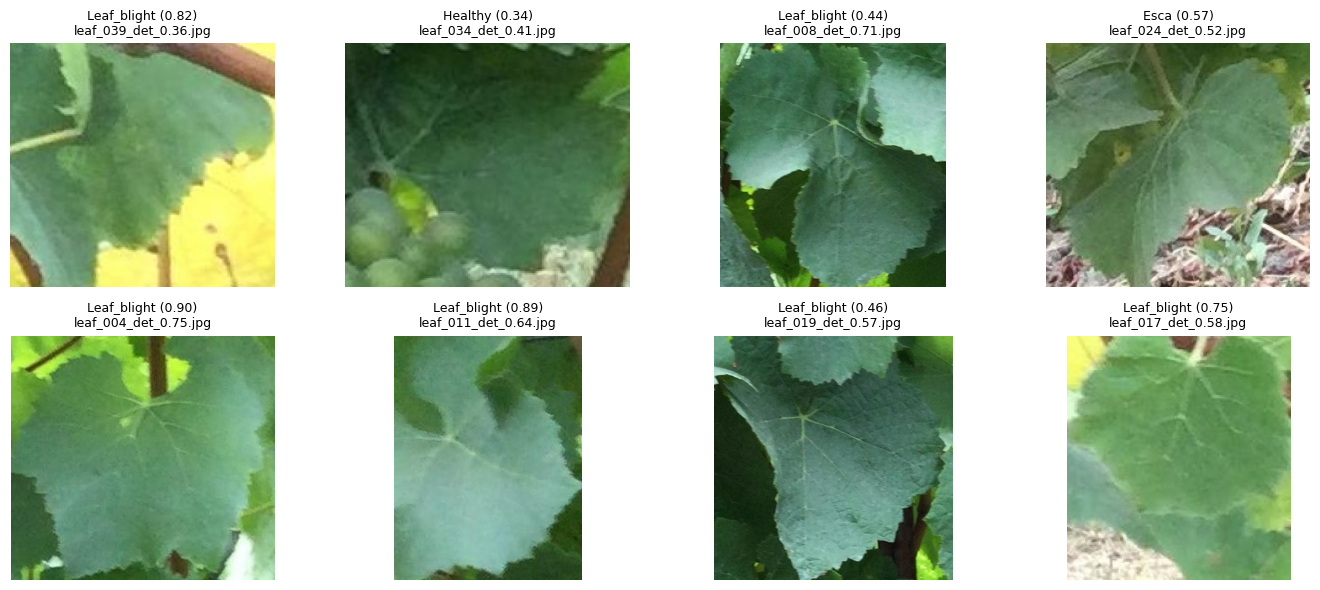

✓ Displayed 8 sample predictions


In [72]:
# ==== Visualize sample predictions ====
import random

if len(detections) > 0:
    # Select random samples with predictions
    samples_with_pred = [d for d in detections if "disease_class" in d and "crop_path" in d]
    
    if len(samples_with_pred) > 0:
        num_samples = min(8, len(samples_with_pred))
        sample_dets = random.sample(samples_with_pred, num_samples)
        
        images, preds, paths = [], [], []
        for d in sample_dets:
            img_path = Path(d["crop_path"])
            img_pil = Image.open(img_path).convert('RGB')
            pred_label = f"{d['disease_class']} ({d['disease_conf']:.2f})"
            
            images.append(img_pil)
            preds.append(pred_label)
            paths.append(img_path.name)
        
        # Visualize
        cols = 4
        rows = int(np.ceil(num_samples / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
        axes = np.atleast_1d(axes).flatten()
        
        for ax, img, pred, path in zip(axes, images, preds, paths):
            ax.imshow(img)
            ax.set_title(f"{pred}\n{path}", fontsize=9)
            ax.axis("off")
        
        for ax in axes[len(images):]:
            ax.axis("off")
        
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Displayed {num_samples} sample predictions")
    else:
        print("No predictions available to visualize.")
else:
    print("No detections to visualize.")


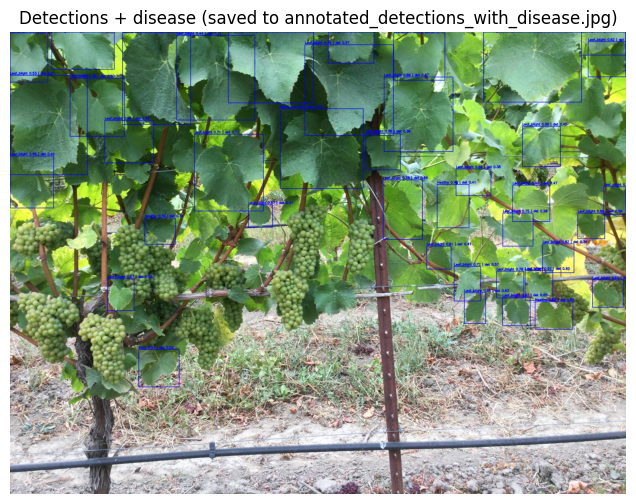

In [29]:
# ==== Annotate image with disease predictions and save ====
if len(detections) == 0:
    print("No detections to annotate.")
else:
    annot2 = img_bgr.copy()
    for d in detections:
        x1,y1,x2,y2 = d["x1"], d["y1"], d["x2"], d["y2"]
        if "disease_class" in d:
            label = f"{d['disease_class']} {d['disease_conf']:.2f} | det {d['det_conf']:.2f}"
            color = (255,0,0)
        else:
            label = f"det {d['det_conf']:.2f}"
            color = (0,255,0)
        cv2.rectangle(annot2, (x1,y1), (x2,y2), color, 2)
        cv2.putText(annot2, label, (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    out_path = OUT_DIR / "annotated_detections_with_disease.jpg"
    cv2.imwrite(str(out_path), annot2)
    show_rgb(cv2.cvtColor(annot2, cv2.COLOR_BGR2RGB), f"Detections + disease (saved to {out_path.name})")


## Outputs

Artifacts are saved under `OUT_DIR`:

- `annotated_detections.jpg` (leaf boxes)
- `annotated_detections_with_disease.jpg` (leaf boxes + disease)
- `crops/` (cropped leaves)
- `leaf_predictions.csv` and `leaf_predictions.json`
